In [20]:
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime, timedelta
import sqlite3
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.metrics import classification_report, precision_recall_curve, mean_absolute_error
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [21]:
conn = sqlite3.connect('flight.db')
cursor = conn.cursor()

### Data Visualization

In [ ]:
#df1 holds all average delay times
query1 = """
        SELECT a.latitude, a.longitude, AVG(f.weather_delay_time) AS avg_w_delay
        FROM flights f LEFT JOIN airports a
        ON f.airport_id = a.airport_id
        GROUP BY a.latitude, a.longitude
"""
df1 = pd.read_sql(query1, conn)
#df2 holds all average precipitation
query2 = """
        SELECT latitude, longitude, AVG(precip) AS avg_precip
        FROM weather
        GROUP BY latitude, longitude
"""
df2 = pd.read_sql(query2, conn)

#merge to match each avg precip to each avg delay time
df_heat_map = pd.merge(df1, df2, on = ['latitude','longitude'], how = 'inner')

plt.figure(figsize=(11, 7))
#Restrict map to only US Mainland
df_heat_map = df_heat_map[(df_heat_map['longitude'] < 0) & (df_heat_map['latitude'] > 20) &
                            (df_heat_map['longitude'] > -130) ]
heat_map = plt.scatter(y = df_heat_map['latitude'], x = df_heat_map['longitude'], 
                       c = df_heat_map['avg_precip'], s = 50*df_heat_map['avg_w_delay'], cmap='viridis',
            alpha=0.8, edgecolors='w',linewidth=0.5)
cbar = plt.colorbar(heat_map)
cbar.set_label('Average Precipitation (mm/hr)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Average Weather Delay and Precipitation ' +
'at Scheduled Departure Times per Airport in Mainland USA')
plt.show()

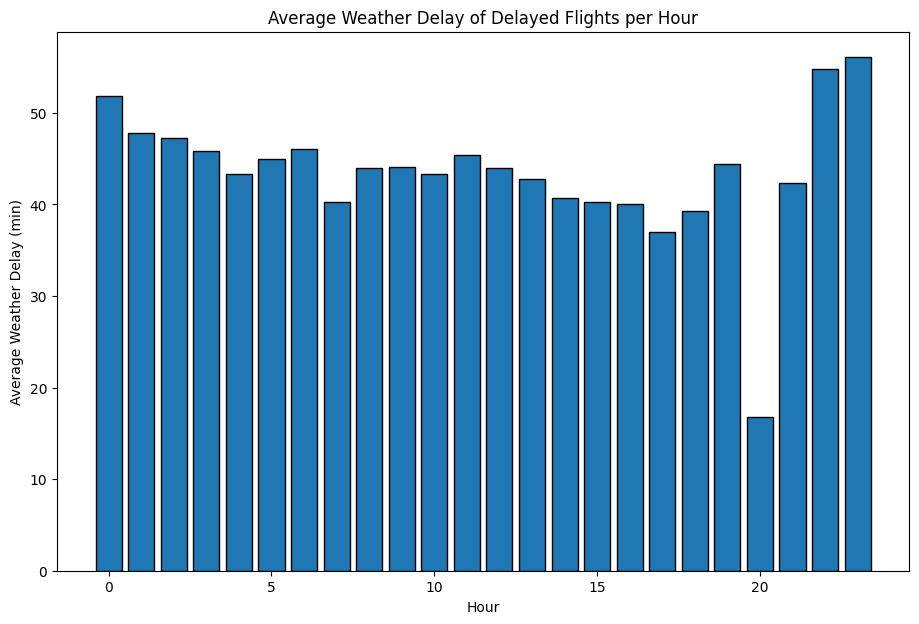

In [4]:
#Get delay times of delayed flights
query = """
    SELECT scheduled_date, weather_delay_time FROM flights WHERE weather_delay_time >0;
"""
delay_vs_time = pd.read_sql(query, conn)
#get hour of each flight
delay_vs_time['scheduled_date'] = pd.to_datetime(delay_vs_time['scheduled_date']).dt.round('h')
delay_vs_time['hour'] = pd.to_datetime(delay_vs_time['scheduled_date']).dt.hour

#remove outliers for ease of comparison
quartile = delay_vs_time['weather_delay_time'].quantile([0.25,0.75])
IQR = quartile[0.75] - quartile[0.25]
delay_vs_time = delay_vs_time[(delay_vs_time['weather_delay_time'] > (quartile[0.25] - 1.5 * IQR)) & (delay_vs_time['weather_delay_time'] < (quartile[0.75] + 1.5*IQR))]
categories  = [i for i in range(0, 24)]
#show average weather delay
quantities = delay_vs_time.groupby('hour')['weather_delay_time'].mean()
plt.figure(figsize=(11, 7))
plt.bar(categories, quantities, edgecolor='black')
plt.xlabel('Hour')
plt.ylabel('Average Weather Delay (min)')
plt.title('Average Weather Delay of Delayed Flights per Hour')
plt.show()

In [ ]:
query = """
    SELECT latitude, longitude, AVG(wind_dir_10) AS avg_wind_direction, AVG(wind_speed_10) AS avg_wind_speed
    FROM weather GROUP BY latitude, longitude
"""
df_wind_map = pd.read_sql(query, conn)
#Generate vectors with magnitude (avg_wind_speed) and angle (avg_wind_direction)
df_wind_map['avg_wind_direction'] = np.deg2rad(df_wind_map['avg_wind_direction'])
df_wind_map['u'] = -df_wind_map['avg_wind_speed'] * np.sin(df_wind_map['avg_wind_direction'])
df_wind_map['v'] = -df_wind_map['avg_wind_speed'] * np.cos(df_wind_map['avg_wind_direction'])
#filter map for mainland USA
df_wind_map = df_wind_map[(df_wind_map['longitude'] < 0) & (df_wind_map['latitude'] > 20) &
                            (df_wind_map['longitude'] > -130) ]
#Plot quiver map of average wind
plt.figure(figsize=(14, 8))
q = plt.quiver(df_wind_map['longitude'], df_wind_map['latitude'], 
               df_wind_map['u'], df_wind_map['v'], 
               df_wind_map['avg_wind_speed'], 
               cmap='viridis', units='width', width=0.002)
plt.colorbar(q, label='Wind Speed (m/s)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Average Wind Speed and Direction per Airport in Mainland USA')
plt.show()

### Data Modeling

In [6]:
#Query for all relevant data for predictions
#Takes about 2.5 minutes to fetch
query = """
        SELECT 
        w1.temp AS s_temp, w1.precip AS s_precip, w1.wind_speed_10 AS s_wind_speed_10, w1.wind_dir_10 AS s_wind_dir_10,
        w1.humidity AS s_humidity, w1.pressure AS s_pressure, w1.cloud_amt AS s_cloud_amt,
        w1.wind_speed_50 AS s_wind_speed_50, w1.wind_dir_50 AS s_wind_dir_50, w1.dew_point AS s_dew_point, 
        w1.spread AS s_spread, w1.ice_risk AS s_ice_risk,
        
        w2.temp AS a_temp, w2.precip AS a_precip, w2.wind_speed_10 AS a_wind_speed_10, w2.wind_dir_10 AS a_wind_dir_10,
        w2.humidity AS a_humidity, w2.pressure AS a_pressure, w2.cloud_amt AS a_cloud_amt,
        w2.wind_speed_50 AS a_wind_speed_50, w2.wind_dir_50 AS a_wind_dir_50, w2.dew_point AS a_dew_point, 
        w2.spread AS a_spread, w2.ice_risk AS a_ice_risk,

        w3.temp AS b_temp, w3.precip AS b_precip, w3.wind_speed_10 AS b_wind_speed_10, w3.wind_dir_10 AS b_wind_dir_10,
        w3.humidity AS b_humidity, w3.pressure AS b_pressure, w3.cloud_amt AS b_cloud_amt,
        w3.wind_speed_50 AS b_wind_speed_50, w3.wind_dir_50 AS b_wind_dir_50, w3.dew_point AS b_dew_point, 
        w3.spread AS b_spread, w3.ice_risk AS b_ice_risk,

        w4.temp AS c_temp, w4.precip AS c_precip, w4.wind_speed_10 AS c_wind_speed_10, w4.wind_dir_10 AS c_wind_dir_10,
        w4.humidity AS c_humidity, w4.pressure AS c_pressure, w4.cloud_amt AS c_cloud_amt,
        w4.wind_speed_50 AS c_wind_speed_50, w4.wind_dir_50 AS c_wind_dir_50, w4.dew_point AS c_dew_point, 
        w4.spread AS c_spread, w4.ice_risk AS c_ice_risk,

        f.cancelled, f.month, f.weather_delay_time, f.day_of_week, a.latitude, a.longitude
        FROM flights f 
        JOIN airports a 
        ON f.airport_id = a.airport_id
        LEFT JOIN weather w1
        ON a.latitude = w1.latitude AND a.longitude = w1.longitude AND f.scheduled_date_round_utc = w1.date
        LEFT JOIN weather w2
        ON a.latitude = w2.latitude AND a.longitude = w2.longitude AND datetime(f.scheduled_date_round_utc, '-1 hours') = w2.date
        LEFT JOIN weather w3
        ON a.latitude = w3.latitude AND a.longitude = w3.longitude AND datetime(f.scheduled_date_round_utc, '-2 hours') = w3.date
        LEFT JOIN weather w4
        ON a.latitude = w4.latitude AND a.longitude = w4.longitude AND datetime(f.scheduled_date_round_utc, '-4 hours') = w4.date
"""
df = pd.read_sql(query, conn)


In [7]:
#Feature Engineering:
#Turn date data into cyclic data: January near December and Sunday near Monday
df['month'] = np.sin(2 * np.pi * df['month'] / 12)
df['day_of_week'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
#Feature engineering for model
df['is_weather_delay'] = df['weather_delay_time'] > 0
def create_bins(minutes):
    if minutes <= 30: 
        return 0      
    if minutes <= 90: 
        return 1    
    else:
        return 2           

df['delay_cat'] = df['weather_delay_time'].apply(create_bins)
#classification for model
features = df.columns.tolist()
predicting = ['cancelled','weather_delay_time', 'is_weather_delay', 'delay_cat']
features = [item for item in features if item not in predicting]
numeric = features

In [8]:
#Model 1: Is Cancelled or Not
#Transformers scales values and takes care of missing values
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric)
    ])

#XGB Classifier Pipeline deals with skewed distribution
is_cancelled = ImbPipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', xgb.XGBClassifier(
                                            objective='binary:logistic',      
                                            eval_metric='aucpr',                
                                            n_estimators=1000,                 
                                            learning_rate=0.02,               
                                            max_depth=8,             
                                            scale_pos_weight= 15, #Emphasizes cancelled flights
                                            subsample=0.7,                    
                                            colsample_bytree=0.7,             
                                            gamma=0.5,                       
                                            reg_lambda=50,        #emphasizes cancelled flights
                                            reg_alpha =5,
                                            random_state=42))])


#Train, test, and evaluate
X_train1, X_test1, y_train1, y_test1 = train_test_split(df[features], df['cancelled'], test_size=0.2, random_state=12, stratify = df['cancelled'])
is_cancelled.fit(X_train1, y_train1)
y_pred1 = is_cancelled.predict(X_test1)
print('Model 1: Is the flight cancelled or not?\n')
#Print evaluation metrics
print(f'Accuracy: {accuracy_score(y_test1, y_pred1)}')
print(f'F1-score: {f1_score(y_test1, y_pred1)}\n')
print(f'Confusion Matrix: \n{confusion_matrix(y_test1, y_pred1)}')


Model 1: Is the flight cancelled or not?

Accuracy: 0.9818468450963691
F1-score: 0.28186804055177

Confusion Matrix: 
[[931445  11526]
 [  5758   3392]]


In [9]:
#Find optimal threshold probabilty based on maximum F1 score
y_probs1 = is_cancelled.predict_proba(X_test1)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test1, y_probs1)
f1_scores1 = 2 * (precision * recall) / (precision + recall)
best_threshold1 = thresholds[np.argmax(f1_scores1)]
print('Model 1: Is the flight cancelled or not? Adjusted:\n')
#Evaluation metrics
print(f"Best possible F1-score: {np.max(f1_scores1)}")
print(f"Achieved at Threshold: {best_threshold1}")
y_pred_adjusted1 = (y_probs1 >= best_threshold1).astype(int)
print(f'Accuracy: {accuracy_score(y_test1, y_pred_adjusted1)}\n')
print(f'Confusion Matrix: \n{confusion_matrix(y_test1, y_pred_adjusted1)}')


Model 1: Is the flight cancelled or not? Adjusted:

Best possible F1-score: 0.3139843243561789
Achieved at Threshold: 0.6364709138870239
Accuracy: 0.9877736128076159

Confusion Matrix: 
[[937816   5155]
 [  6486   2664]]


In [10]:
#Model 2: Is the flight Delayed?

is_delayed = ImbPipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', xgb.XGBClassifier(
                                            objective='binary:logistic',      
                                            eval_metric='aucpr',                
                                            n_estimators=1000,                 
                                            learning_rate=0.02,               
                                            max_depth=6,             
                                            scale_pos_weight= 15, #Emphasize delayed flight
                                            subsample=0.7,                    
                                            colsample_bytree=0.7,             
                                            gamma=0.5,                       
                                            reg_lambda=50,        #Emphasize delayed flight
                                            reg_alpha =5,
                                            random_state=42))])

X_train2, X_test2, y_train2, y_test2 = train_test_split(df[features], df['is_weather_delay'], test_size=0.2, random_state=12, stratify = df['is_weather_delay'])
is_delayed.fit(X_train2, y_train2)
y_pred2 = is_delayed.predict(X_test2)

print('Model 2: Is the flight delayed or not?\n')
#Evaluation metrics
print(f'Accuracy: {accuracy_score(y_test2, y_pred2)}')
print(f'F1-score: {f1_score(y_test2, y_pred2)}\n')
print(f'Confusion Matrix: \n{confusion_matrix(y_test2, y_pred2)}')


Model 2: Is the flight delayed or not?

Accuracy: 0.9557419697706488
F1-score: 0.23499083201713777

Confusion Matrix: 
[[903510  34155]
 [  7984   6472]]


In [11]:
#Find optimal threshold probabilty based on maximum F1 score

y_probs2 = is_delayed.predict_proba(X_test2)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test2, y_probs2)
f1_scores2 = 2 * (precision * recall) / (precision + recall)
best_threshold2 = thresholds[np.argmax(f1_scores2)]

print('Model 2: Is the flight delayed or not? Adjusted:\n')
#Evaluation metrics
print(f"Best possible F1-score: {np.max(f1_scores2)}")
print(f"Achieved at Threshold: {best_threshold2}")
y_pred_adjusted2 = (y_probs2 >= best_threshold2).astype(int)
print(f'Accuracy: {accuracy_score(y_test2, y_pred_adjusted2)}')
print(f'Confusion Matrix: \n{confusion_matrix(y_test2, y_pred_adjusted2)}')


Model 2: Is the flight delayed or not? Adjusted:

Best possible F1-score: 0.261158349795299
Achieved at Threshold: 0.6261236071586609
Accuracy: 0.9728952517589676
Confusion Matrix: 
[[921753  15912]
 [  9895   4561]]


In [12]:
#Model 3: If delayed, how long will the flight be delayed for
from sklearn.metrics import mean_squared_error, r2_score
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()) # Scale numerical features
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric)
    ])

delay_min = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', xgb.XGBRegressor(
                                    n_estimators = 5000,
                                    learning_rate=0.005,        
                                    max_depth = 5,
                                    objective='reg:gamma',      #Takes skewed distribution into account
                                    colsample_bytree = 0.8,
                                    tree_method = 'hist',
                                    random_state= 42,
                                    min_child_weight = 5        #Takes skewed distribution into account
                                ))])

#Makes sure only delayed flights are trained/tested
df_reg = df[df['is_weather_delay']]
#Remove outliers
quartile = df_reg['weather_delay_time'].quantile([0.25,0.75])
IQR = quartile[0.75] - quartile[0.25]
df_reg = df_reg[(df_reg['weather_delay_time'] > (quartile[0.25] - 1.5 * IQR)) & (df_reg['weather_delay_time'] < (quartile[0.75] + 1.5*IQR))]

X_train3, X_test3, y_train3, y_test3 = train_test_split(df_reg[features], df_reg['weather_delay_time'], test_size=0.2, random_state=12)

delay_min.fit(X_train3, y_train3)
y_pred3 = delay_min.predict(X_test3)
mse3 = mean_squared_error(y_test3, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y_test3, y_pred3)
print('Model 3: If delayed, how long is the flight delayed?')
#Evaluation metrics
print(f"\nMean Squared Error (MSE): {mse3:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse3:.2f}")
print(f"R-squared (R2) Score: {r23:.2f}")
print(f"MAE: {mean_absolute_error(y_test3, y_pred3)}")

Model 3: If delayed, how long is the flight delayed?

Mean Squared Error (MSE): 1562.53
Root Mean Squared Error (RMSE): 39.53
R-squared (R2) Score: 0.06
MAE: 29.930356180853366


In [ ]:
#Plot residuals for analysis
residual = y_test3 - y_pred3
plt.figure(figsize=(10, 6))
plt.scatter(y_pred3, residual, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel("Predicted Delay (min)")
plt.ylabel("Residual (min)")
plt.title("Residual vs. Predicted Delay")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [14]:
#Model 4: If delayed, what category of delay is it?
df_bin = df[df['is_weather_delay']]
X_train4, X_test4, y_train4, y_test4 = train_test_split(df_bin[features], df_bin['delay_cat'], test_size=0.2, random_state=12, stratify=df_bin['delay_cat'])

from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight='balanced', y=y_train4)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric)
    ])

delay_class_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=9,
        max_delta_step=5,
        gamma = 0.5,
        reg_alpha = 5,
        subsample=0.7,
        colsample_bytree = 0.7,
        reg_lambda=50,
        objective='multi:softprob',
        num_class=3,
        tree_method='hist',
        random_state=42
    ))
])

#Train/test only on delayed flights
delay_class_pipeline.fit(X_train4, y_train4, classifier__sample_weight=weights)
y_pred4 = delay_class_pipeline.predict(X_test4)
print('Model 4: If delayed, what category of delay is it?')
#Evaluation metrics
print(f"Overall Accuracy: {accuracy_score(y_test4, y_pred4):.4f}")
print("\nClassification Report:")
print(classification_report(y_test4, y_pred4, target_names=['Short', 'Medium', 'Large']))


Model 4: If delayed, what category of delay is it?
Overall Accuracy: 0.4744

Classification Report:
              precision    recall  f1-score   support

       Short       0.60      0.54      0.57      6726
      Medium       0.40      0.40      0.40      4561
       Large       0.36      0.45      0.40      3170

    accuracy                           0.47     14457
   macro avg       0.46      0.46      0.46     14457
weighted avg       0.49      0.47      0.48     14457



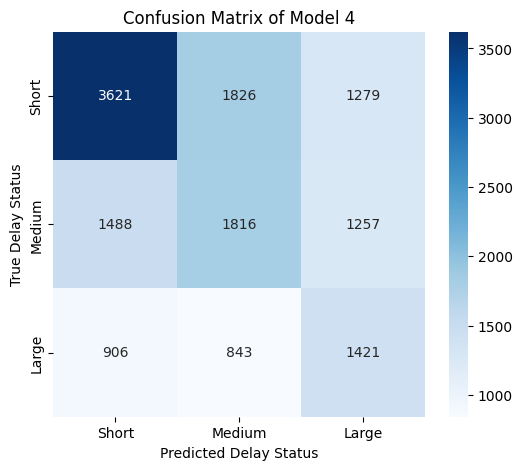

In [15]:
#Confusion Matrix
plt.figure(figsize=(6, 5))
cm =confusion_matrix(y_test4, y_pred4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Short', 'Medium', 'Large'],
            yticklabels=['Short', 'Medium', 'Large'])
plt.xlabel('Predicted Delay Status')
plt.ylabel('True Delay Status')
plt.title('Confusion Matrix of Model 4')
plt.show()



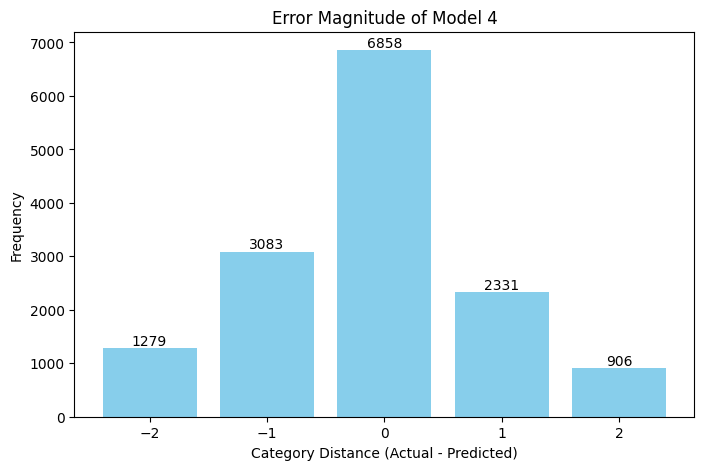

In [16]:
#Histogram to better understand confusion matrix

categories = [-2,-1,0,1,2]
df_diff= pd.concat([y_test4.reset_index(drop=True), pd.Series(y_pred4)], axis=1)
df_diff.columns = ['act_cat', 'pred_cat']
df_diff['diff'] = df_diff['act_cat'] - df_diff['pred_cat']
quantities = []
for cat in categories:
    quantities.append(len(df_diff[df_diff['diff'] == cat]))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, quantities, color='skyblue')
for bar in bars:
    yval = bar.get_height() # Get the height of the bar
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom')
plt.title('Error Magnitude of Model 4')
plt.xlabel('Category Distance (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

In [24]:
conn.close()